<a href="https://colab.research.google.com/github/APMAPM1/Langgraph-demo/blob/create%2Fbasic_langgraph/Chatbot_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.4 MB/s eta 0:00:00


In [7]:
!pip install python-dotenv
!pip install langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.7/126.7 kB 3.7 MB/s eta 0:00:00


In [8]:
!pip install arxiv
!pip install wikipedia

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 2.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=fb87259bac9c9a2bf8eef15983cd9118450304ac178c860dd6af116cabf9a80f
  Stored in directory: /root/.cache/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built sgmllib3k
  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=59dfdad2554c394d99fe3a16362b3968d82dd343175e0fd6b6c1d4773d2852aa
  Stored in directory: /root/.cache/pip/wheels/8f/ab/cb/45ccc40522d3a1c41e1d2ad53b8f33a62f394011ec38cd71c6
Successfully built wikipedia


In [61]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [63]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [64]:
arxiv.invoke("What is the largest research on quantum computing?")

'Published: 2023-05-23\nTitle: Fast and energy-efficient non-volatile III-V-on-silicon photonic phase shifter based on memristors\nAuthors: Zhuoran Fang, Bassem Tossoun, Antoine Descos, Di Liang, Xue Huang, Geza Kurczveil, Arka Majumdar, Raymond G. Beausoleil\nSummary: Silicon photonics has evolved from lab research to commercial products in the\npast decade as it plays an increasingly crucial role in data communication for\nnext-generation data centers and high performance computing1. Recently,\nprogr'

In [65]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [85]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]="your key"
os.environ["GROQ_API_KEY"]="your key"

In [86]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

In [68]:
tavily.invoke("Provide me the recent AI news?")

[{'title': 'AI News | Latest AI News, Analysis & Events',
  'url': 'https://www.artificialintelligence-news.com/',
  'content': 'March 4, 2025\nAutoscience Carl: The first AI scientist writing peer-reviewed papers\nApplications\nMarch 3, 2025\nDeep Learning\nAlibaba Qwen QwQ-32B: Scaled reinforcement learning showcase\nArtificial Intelligence\nMarch 6, 2025\nDeepSeek-R1 reasoning models rival OpenAI in performance\nArtificial Intelligence\nJanuary 20, 2025\nNew AI training techniques aim to overcome current challenges\nDeep & Reinforcement Learning\nNovember 28, 2024 [...] Artificial Intelligence\nMarch 14, 2025\nOpenAI and Google call for US government action to secure AI lead\n\nArtificial Intelligence\nMarch 14, 2025\nCBRE: Leveraging Artificial Intelligence for business growth\n\nAGI\nMarch 14, 2025\nManus AI agent: breakthrough in China’s agentic AI\n\nApplications\nMarch 13, 2025\nServiceNow deploys AI agents to boost enterprise workflows [...] AI News\nMarch 20, 2025\nUK ministe

In [69]:
tools=[arxiv, wiki, tavily]

In [70]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen-qwq-32b")

In [71]:
llm.invoke("What is AI")

AIMessage(content='\n<think>\nOkay, so I need to explain what AI is. Let me start by recalling what I know. AI stands for Artificial Intelligence, right? From what I\'ve heard, it\'s about making machines that can perform tasks that usually need human intelligence. But wait, what tasks exactly? Maybe things like problem-solving, learning, recognizing patterns, decision-making, understanding language?\n\nHmm, I should make sure to distinguish between types of AI. There\'s general AI and narrow AI. General AI would be like a machine that can handle any intellectual task a human can, but I think that\'s still theoretical. Current AI is mostly narrow, like voice assistants, recommendation systems, or self-driving cars. Each of those is good at a specific task but not others.\n\nAlso, how does AI work? I remember something about machine learning, which is a subset of AI. Machine learning involves training models on data so they can make predictions or decisions. There\'s supervised learning

In [72]:
llm_with_tools=llm.bind_tools(tools=tools)

In [73]:
llm_with_tools.invoke("What is the recent news on AI?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_xtjb', 'function': {'arguments': '{"query": "recent news on AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 179, 'prompt_tokens': 356, 'total_tokens': 535, 'completion_time': 0.44496036, 'prompt_time': 0.092348477, 'queue_time': 1.483412584, 'total_time': 0.537308837}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_3796682456', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d415f826-fb7f-47a8-b36c-d5573df85f4f-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent news on AI'}, 'id': 'call_xtjb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 356, 'output_tokens': 179, 'total_tokens': 535})

In [29]:
!pip install langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.0/145.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 16.2 MB/s eta 0:00:00


In [74]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [75]:
class State(TypedDict):
    message: Annotated[list[AnyMessage], add_messages]

In [93]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

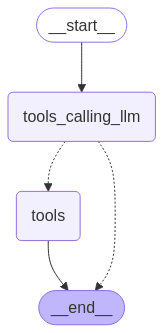

In [102]:
def tools_calling_llm(state:State):
  return {"message": [llm_with_tools.invoke(state["message"])]}

builder=StateGraph(State)
builder.add_node("tools_calling_llm", tools_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [103]:
from langchain_core.messages import HumanMessage, AIMessage

state = {"message": [HumanMessage(content="My name is Aditi")]}
intermediate_state = graph.nodes["tools_calling_llm"].invoke(state)
# Instead of partial_invoke, directly invoke from the desired node
result = graph.nodes["tools_calling_llm"].invoke(intermediate_state) # Changed this line

for msg in result["message"]:
    msg.pretty_print()



================================== Ai Message ==================================

Hello! It's nice to meet you too! 😊 If you have any questions or need help with anything—whether it's looking up information, explaining a concept, or finding resources—just let me know! I'm here to help!
